# Comprehensive analysis — one notebook, every plot

**Flow** (top-to-bottom, edit as you go):
1. Setup + load a pair
2. Heatmaps (aligned R², shuffled R², ΔR²)
3. Suggest & set `FOCUS_PARAMS`
4. Per-parameter mean-net plots: predictions, dual curve, bias progression, pair-normalized, shuffle scatter
5. Moment-network plots: marginal posterior 1D+grid, σ bars, calibration pull
6. Cross-pair comparison
7. Save any current figure
8. Scratch cell

Change `PAIR_IDX` in section 1 and rerun downstream to switch pairs.

In [1]:
%matplotlib inline
import sys, os, importlib
_HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

# Explicit reload so kernel picks up any recent edits to the helpers or src/plots.py
import _analyze_helpers
importlib.reload(_analyze_helpers)
from _analyze_helpers import (
    load_pair, list_pairs, relabel_figure, label_cases, suggest_params,
    build_dual_r2_df, load_all_pairs, compare_across_pairs,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Load a pair

In [2]:
print("Available:")
for i, name in enumerate(list_pairs()):
    print(f"  {i}: {name}")
print(f"  moment_example/results/results.pt   (moment network — has σ)")

Available:
  0: pair_01_MBH_Mh_s61__SFR_Ms_s90
  moment_example/results/results.pt   (moment network — has σ)


In [3]:
PAIR_IDX = 0                    # 0..3 for sweep pairs
# For the moment example instead:
ctx = load_pair(results_path="moment_example/results/results.pt")
#ctx = load_pair(pair_idx=PAIR_IDX)
ctx.summary()

Pair: MBH_Mh_s61  ×  SFR_Ms_s90
  observable_1 (A) = MBH_Mh_s61
  observable_2 (B) = SFR_Ms_s90
  4 cases:
    A_clean               →  MBH alone
    B_clean               →  SFR alone
    B_0.0_A_0.0           →  SFR=0.0, MBH=0.0
    B_1.0_A_1.0           →  SFR=1.0, MBH=1.0
  Focus params for plots: θ0, θ1, θ2, θ4, θ7, θ11 (adjust as needed)


## 2. Heatmaps

### 2a. Aligned R²

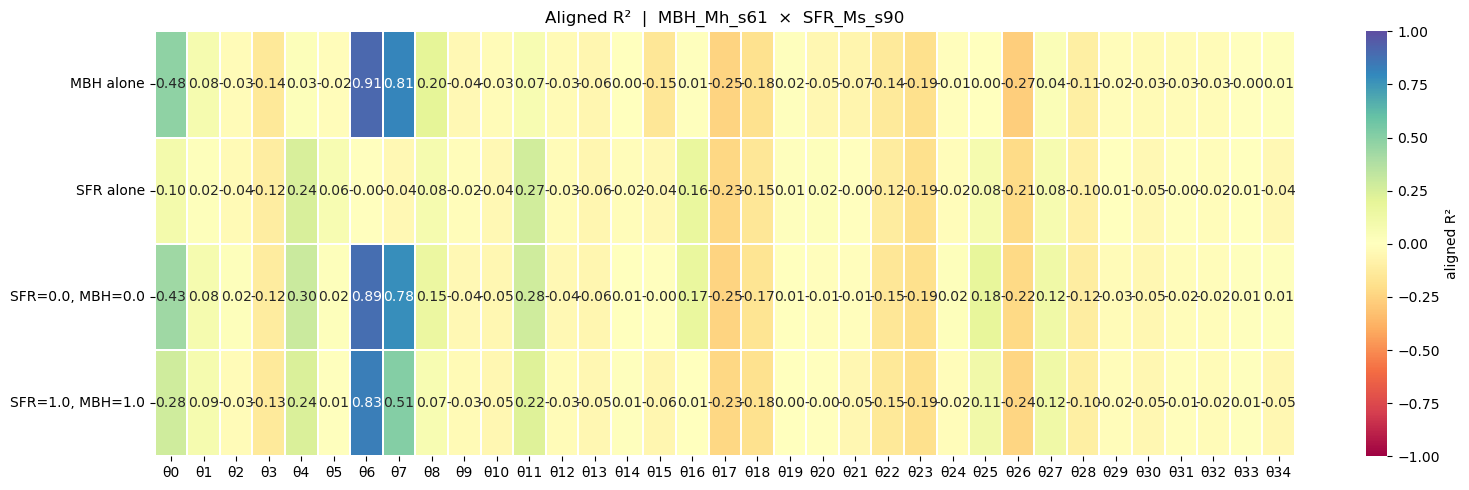

In [4]:
labels = label_cases(ctx, ctx.cases)
df = pd.DataFrame(ctx.r2_matrix, index=labels, columns=ctx.param_names)
plt.figure(figsize=(16, 5))
sns.heatmap(df, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap="Spectral",
            linewidths=0.2, cbar_kws={"label": "aligned R²"})
plt.title(f"Aligned R²  |  {ctx.obs1}  ×  {ctx.obs2}")
plt.tight_layout(); plt.show()

### 2b. Shuffled R² — obs2 shuffled (survives only if model reads obs1)

In [5]:
if ctx.r2_matrix_shifted_obs is not None:
    df = pd.DataFrame(ctx.r2_matrix_shifted_obs, index=labels, columns=ctx.param_names)
    plt.figure(figsize=(16, 5))
    sns.heatmap(df, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap="Spectral",
                linewidths=0.2, cbar_kws={"label": "R² (obs2 shuffled)"})
    plt.title(f"obs2 shuffled  |  {ctx.obs1}  ×  {ctx.obs2}")
    plt.tight_layout(); plt.show()

### 2c. Shuffled R² — obs1 shuffled

In [6]:
if ctx.r2_matrix_shifted_both is not None:
    df = pd.DataFrame(ctx.r2_matrix_shifted_both, index=labels, columns=ctx.param_names)
    plt.figure(figsize=(16, 5))
    sns.heatmap(df, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap="Spectral",
                linewidths=0.2, cbar_kws={"label": "R² (obs1 shuffled)"})
    plt.title(f"obs1 shuffled  |  {ctx.obs1}  ×  {ctx.obs2}")
    plt.tight_layout(); plt.show()

### 2d. ΔR² — obs2 shuffled (negative = information lost)

In [7]:
if ctx.r2_matrix_shifted_obs is not None:
    delta = ctx.r2_matrix_shifted_obs - ctx.r2_matrix
    df = pd.DataFrame(delta, index=labels, columns=ctx.param_names)
    plt.figure(figsize=(16, 5))
    sns.heatmap(df, center=0.0, vmin=-0.5, annot=True, fmt=".2f", cmap="Spectral",
                linewidths=0.3, cbar_kws={"label": "ΔR² (obs2 shuffled)"})
    plt.title(f"ΔR² — obs2 shuffled  |  {ctx.obs1}  ×  {ctx.obs2}")
    plt.tight_layout(); plt.show()

### 2e. ΔR² — obs1 shuffled

In [8]:
if ctx.r2_matrix_shifted_both is not None:
    delta = ctx.r2_matrix_shifted_both - ctx.r2_matrix
    df = pd.DataFrame(delta, index=labels, columns=ctx.param_names)
    plt.figure(figsize=(16, 5))
    sns.heatmap(df, center=0.0, vmin=-0.5, annot=True, fmt=".2f", cmap="Spectral",
                linewidths=0.3, cbar_kws={"label": "ΔR² (obs1 shuffled)"})
    plt.title(f"ΔR² — obs1 shuffled  |  {ctx.obs1}  ×  {ctx.obs2}")
    plt.tight_layout(); plt.show()

## 3. Suggest parameters → set `FOCUS_PARAMS`

In [9]:
suggestions = suggest_params(ctx, top_n=6, min_aligned_r2=0.1)

Suggested parameters (top 6):
  well-constrained   (highest max-case aligned R²):
    θ6      +0.91
    θ7      +0.81
    θ0      +0.48
    θ4      +0.30
    θ11     +0.28
    θ8      +0.20

  Union of the above (paste into FOCUS_PARAMS):
    FOCUS_PARAMS = ['θ6', 'θ7', 'θ0', 'θ4', 'θ11', 'θ8']


In [10]:
FOCUS_PARAMS = suggestions["union"]        # or e.g. ["θ4", "θ7", "θ11"]
print(f"FOCUS_PARAMS = {FOCUS_PARAMS}")

FOCUS_PARAMS = ['θ6', 'θ7', 'θ0', 'θ4', 'θ11', 'θ8']


## 4. Per-parameter mean-net plots

### 4a. Predictions overlaid across cases (per parameter)

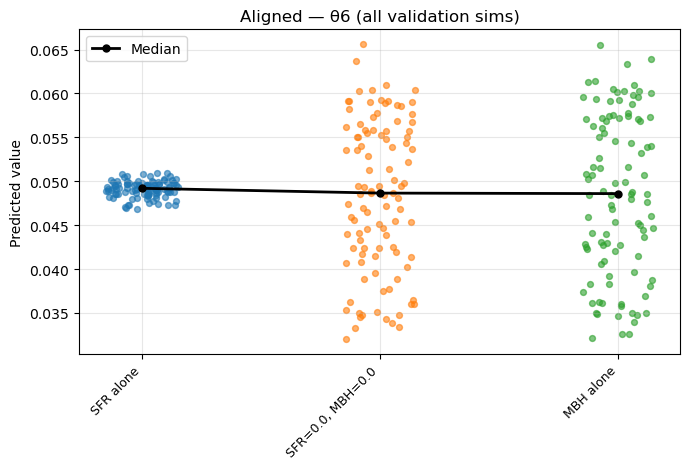

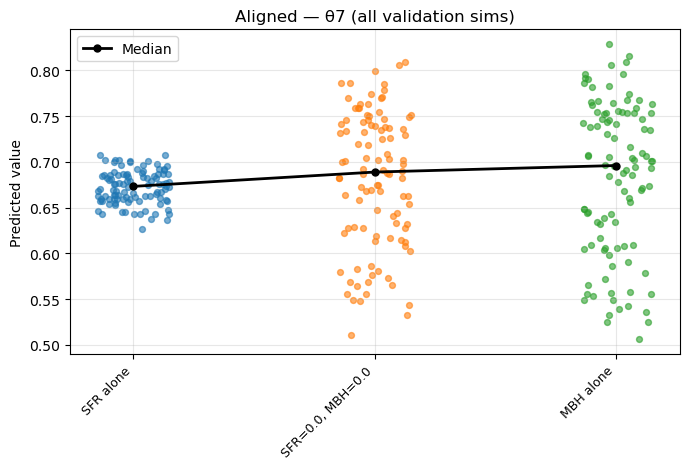

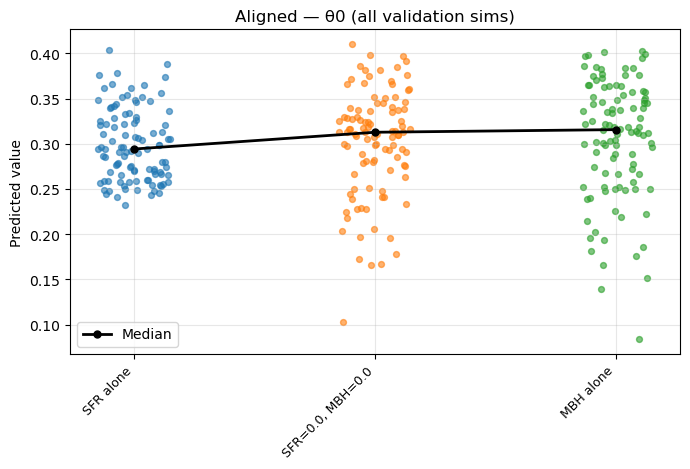

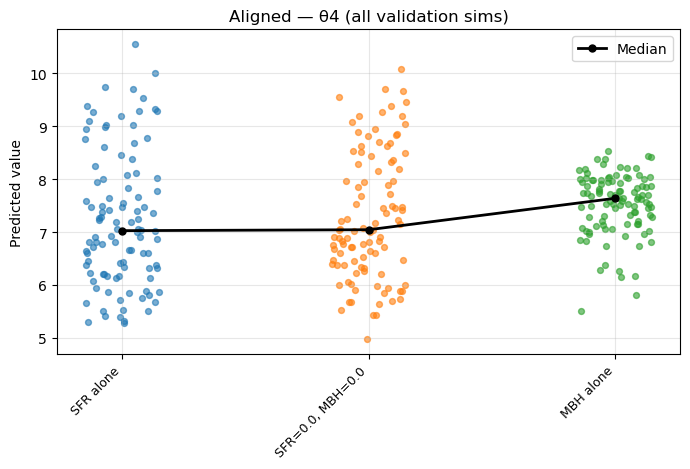

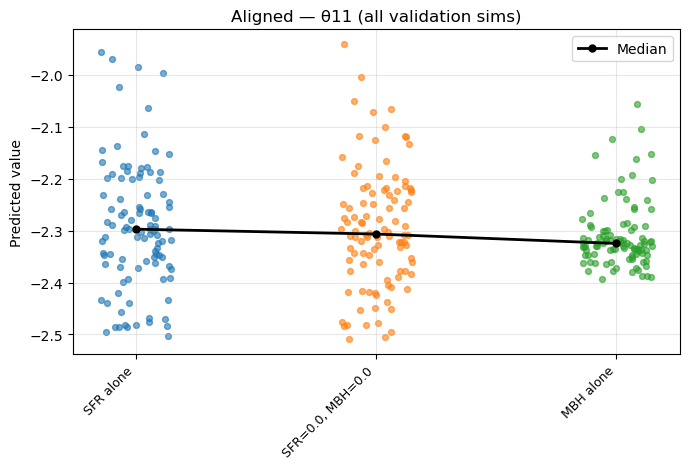

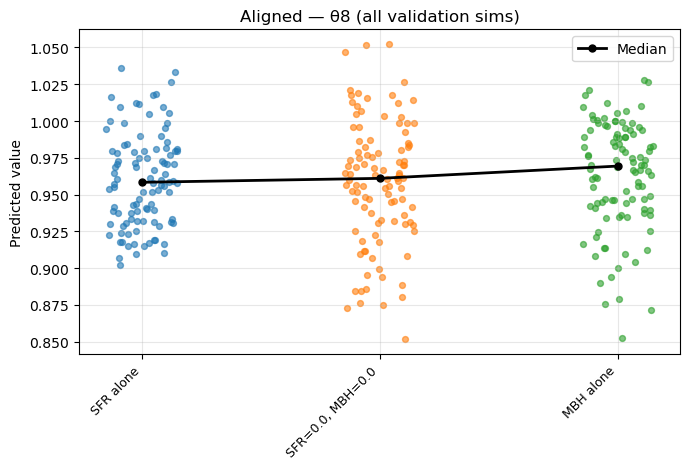

In [11]:
for p in FOCUS_PARAMS:
    ctx.plots.plot_param_all_val(p, mode="aligned")
    relabel_figure(ctx)
    plt.show()

### 4b. Dual-curve — aligned + both shuffle modes with 10-perm ±σ bands

In [12]:
if ctx.r2_matrix_shifted_obs is not None and ctx.r2_matrix_shifted_both is not None:
    dual_r2_df = build_dual_r2_df(ctx)
    for p in FOCUS_PARAMS:
        try:
            ctx.plots.plot_param_curve_dual(dual_r2_df, p, figsize=(8, 5), show_band=True)
            relabel_figure(ctx)
            plt.show()
        except Exception as e:
            print(f"[warn] {p}: {e}")

### 4c. Bias progression overlay
(pred − true) vs true, one curve per case ordered clean→asym→both-clean→asym→clean

/Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/_analyze_helpers.py:430: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


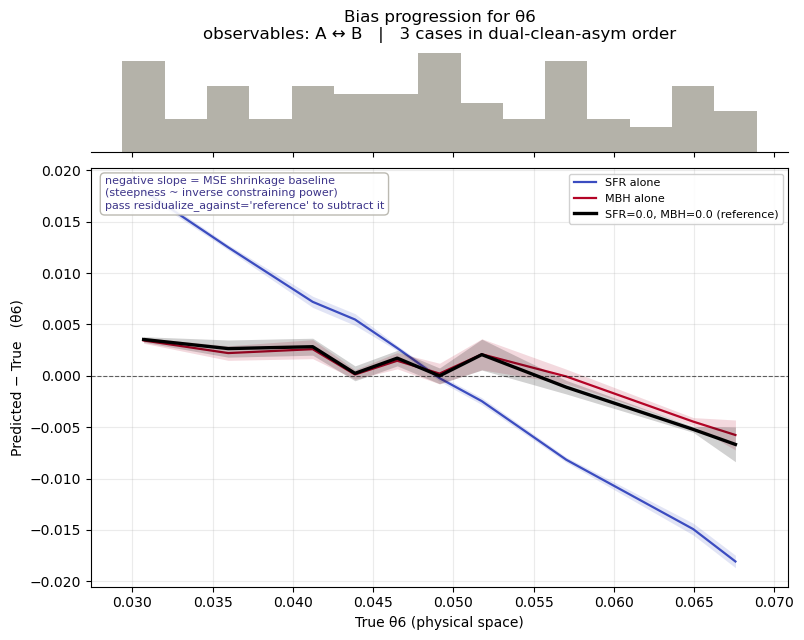

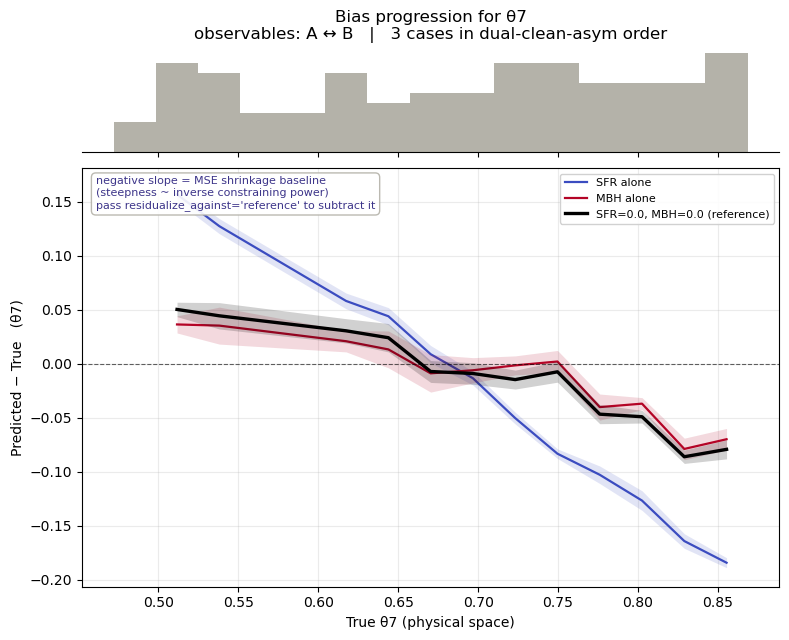

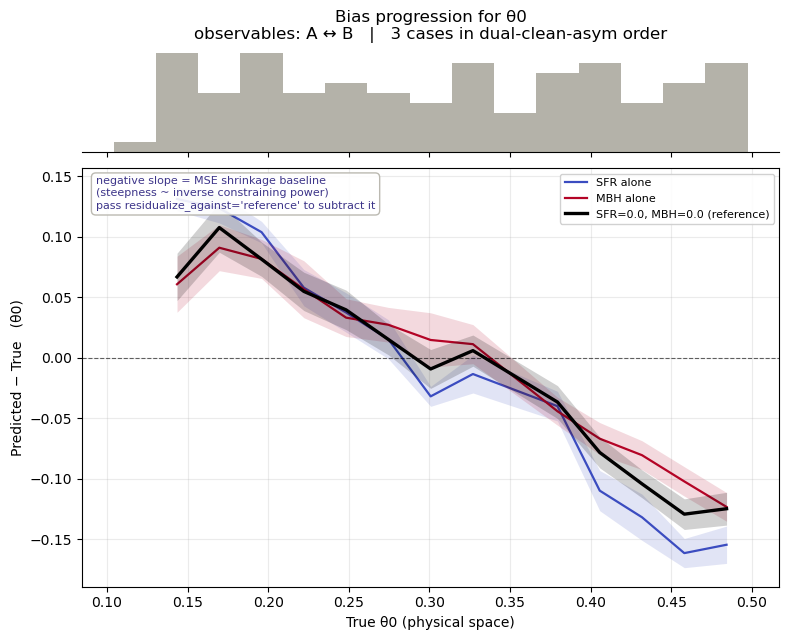

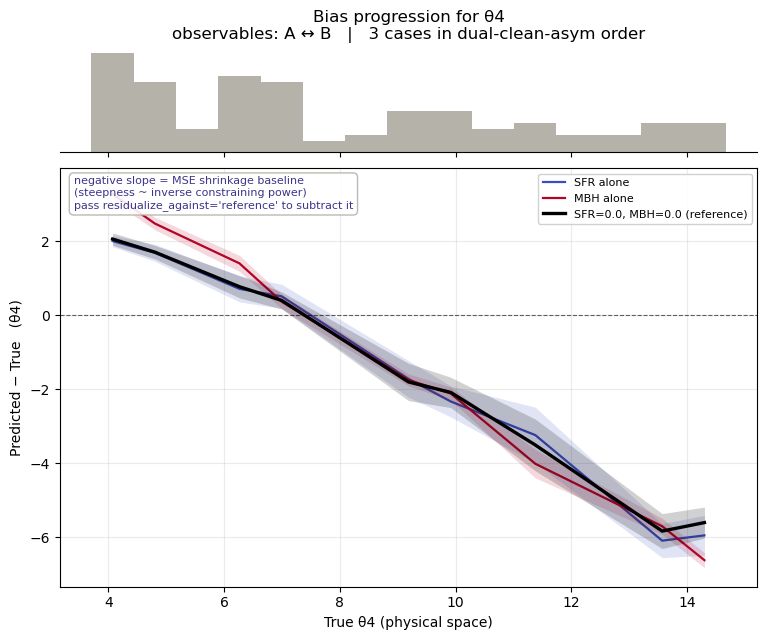

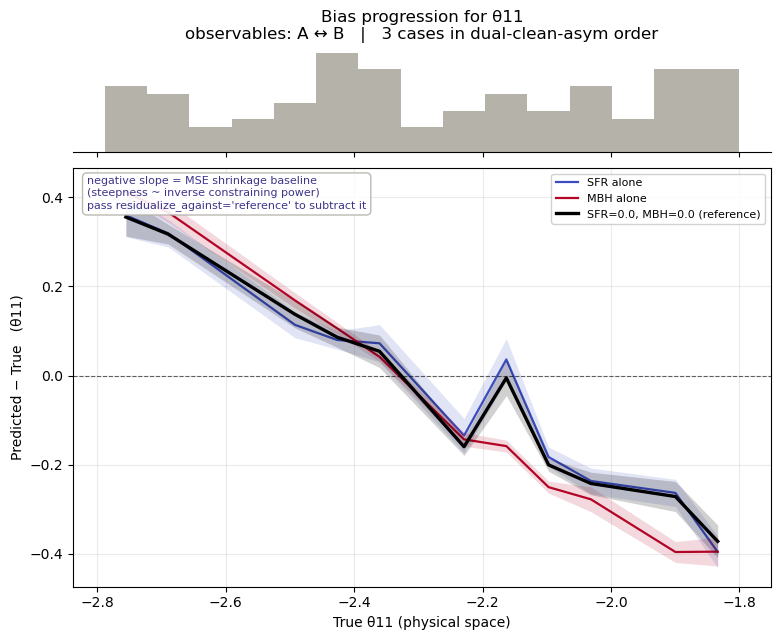

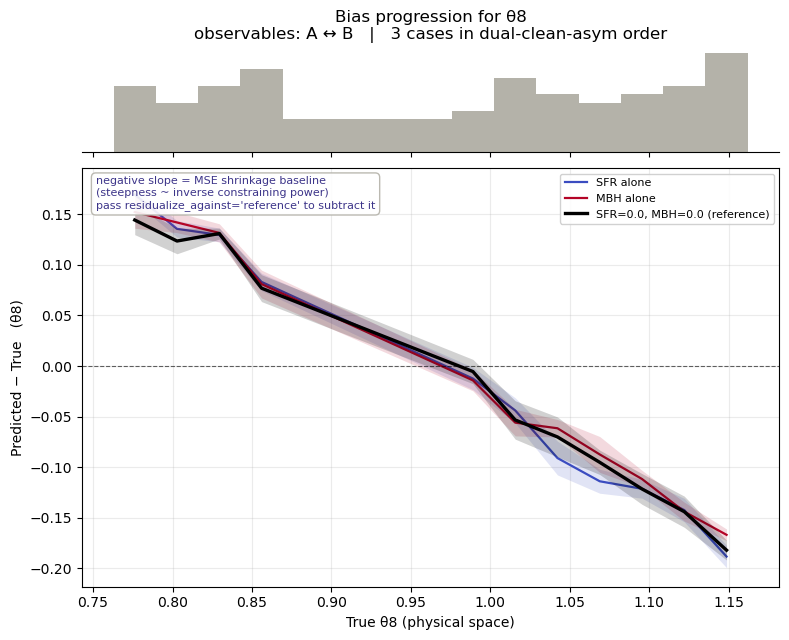

In [13]:
for p in FOCUS_PARAMS:
    try:
        fig, stats = ctx.plots.plot_bias_progression_overlay(param=p)
        relabel_figure(ctx)
        plt.show()
    except Exception as e:
        print(f"[warn] plot_bias_progression_overlay({p}): {e}")

### 4d. Pair-normalized values — one param, one mode

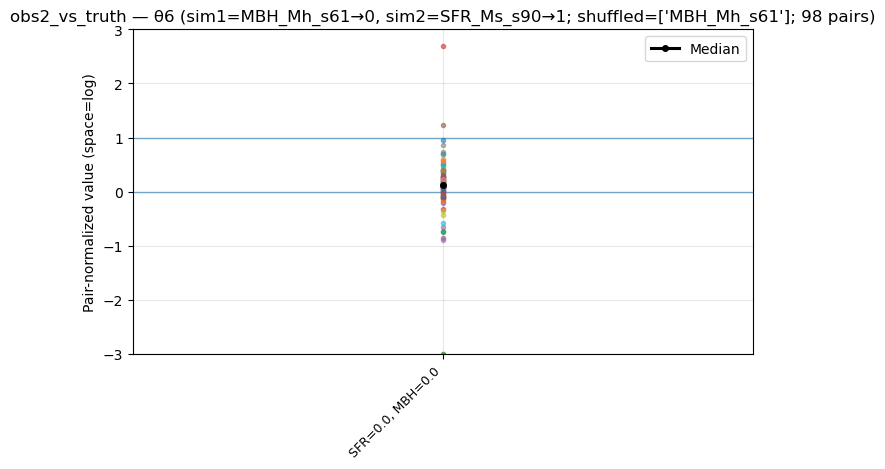

In [14]:
PAIR_PARAM = FOCUS_PARAMS[0] if FOCUS_PARAMS else "θ4"
try:
    ctx.plots.plot_param_pair_normalized_values(
        PAIR_PARAM, space="log",
        mode="obs2_vs_truth",
        normalize_endpoints="obs1_to_obs2",
    )
    relabel_figure(ctx)
    plt.show()
except Exception as e:
    print(f"[warn] plot_param_pair_normalized_values({PAIR_PARAM}): {e}")

### 4e. Side-by-side pair-normalized shuffle scatter

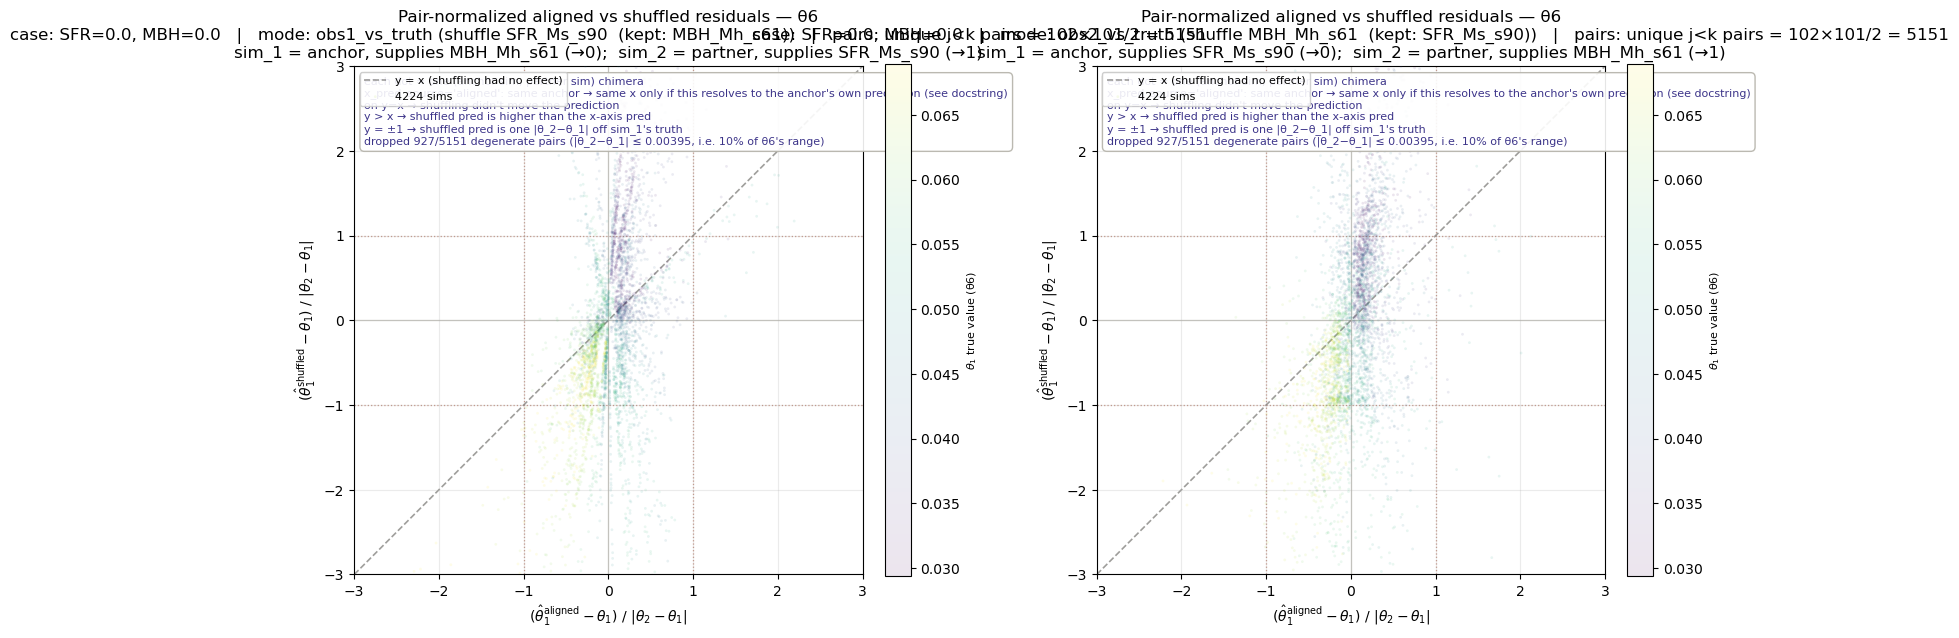

In [15]:
def side_by_side_shuffle_scatter(param):
    fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
    _ax_iter = iter(axes)
    _orig = plt.subplots
    plt.subplots = lambda *a, **k: (fig, next(_ax_iter))
    try:
        ctx.plots.plot_pair_normalized_shuffle_scatter(
            param=param, n_pairs="all", case=None,
            mode="obs1_vs_truth", color_by_theta1=True)
        ctx.plots.plot_pair_normalized_shuffle_scatter(
            param=param, n_pairs="all", case=None,
            mode="obs2_vs_truth", color_by_theta1=True)
    finally:
        plt.subplots = _orig
    fig.tight_layout()
    return fig

SHUFFLE_SCATTER_PARAM = FOCUS_PARAMS[0] if FOCUS_PARAMS else "θ4"
try:
    fig = side_by_side_shuffle_scatter(SHUFFLE_SCATTER_PARAM)
    relabel_figure(ctx, fig)
    plt.show()
except Exception as e:
    print(f"[warn] shuffle_scatter({SHUFFLE_SCATTER_PARAM}): {e}")

# Uncomment to loop:
# for p in FOCUS_PARAMS:
#     fig = side_by_side_shuffle_scatter(p); relabel_figure(ctx, fig); plt.show()

## 5. Moment-network summary plots
Only render if this pair has a moment head. Reload moment_example if needed:
  ctx = load_pair(results_path="moment_example/results/results.pt")

In [16]:
has_moment = getattr(ctx, "has_moment", False) or ctx.has_variance
if not has_moment:
    print("Loaded pair has no moment_model. Load moment_example to see these plots.")

### 5a. Predicted μ ± σ vs true, per param
One panel per case per param. Points inside error bars = well-calibrated.
`pull std = X.XX` printed on each panel — 1.0 is perfect calibration.

[warn] θ6: param 'θ6' not in any case's moment_focus_params.


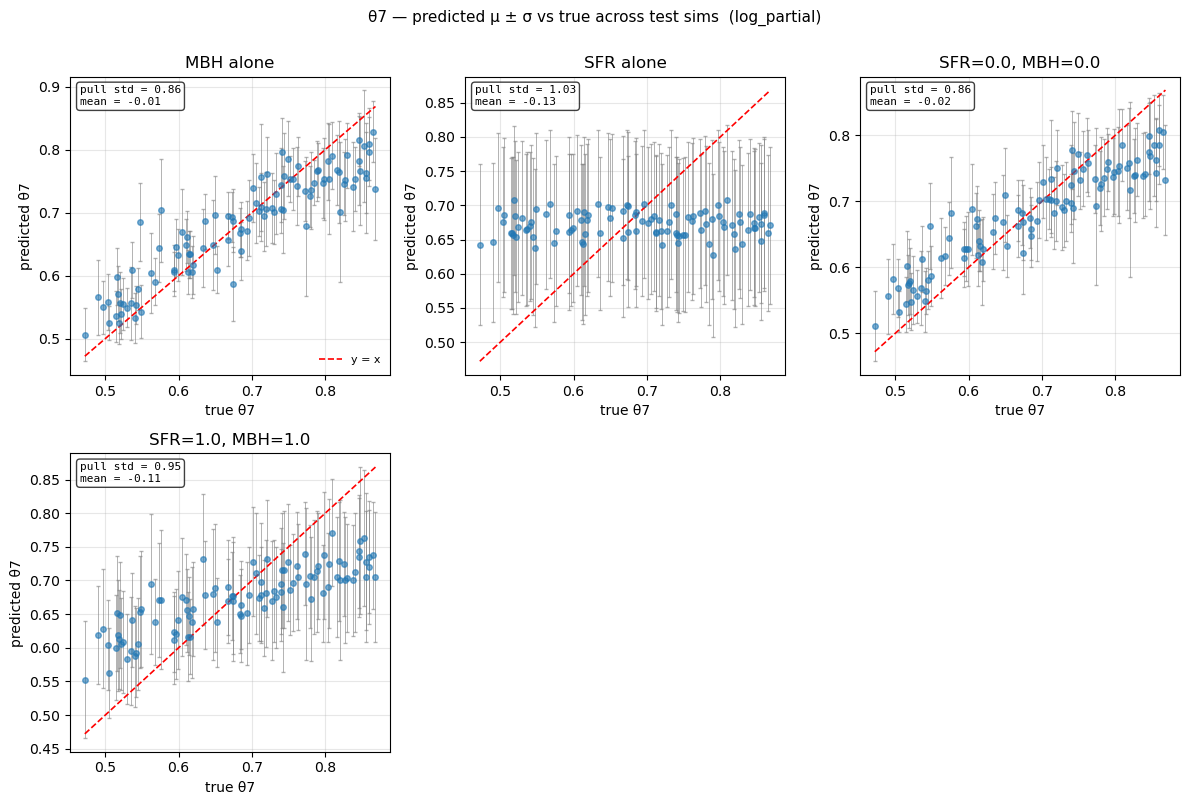

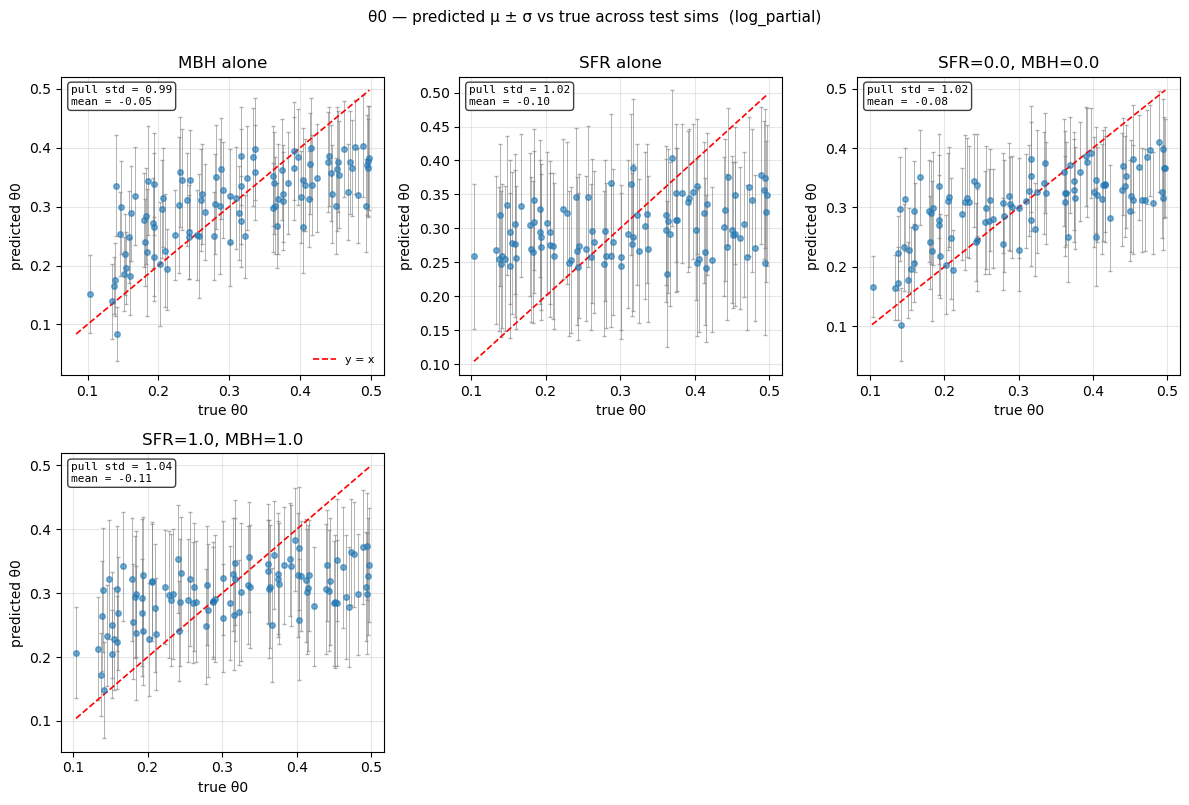

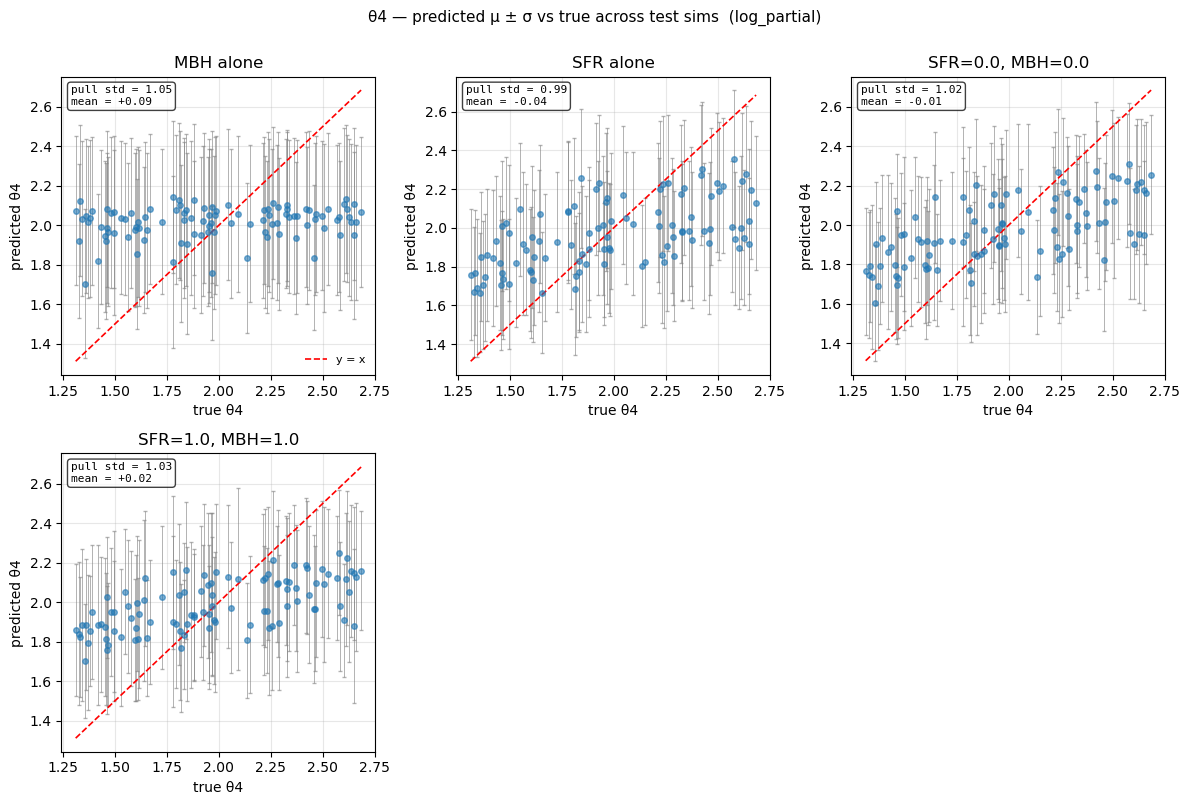

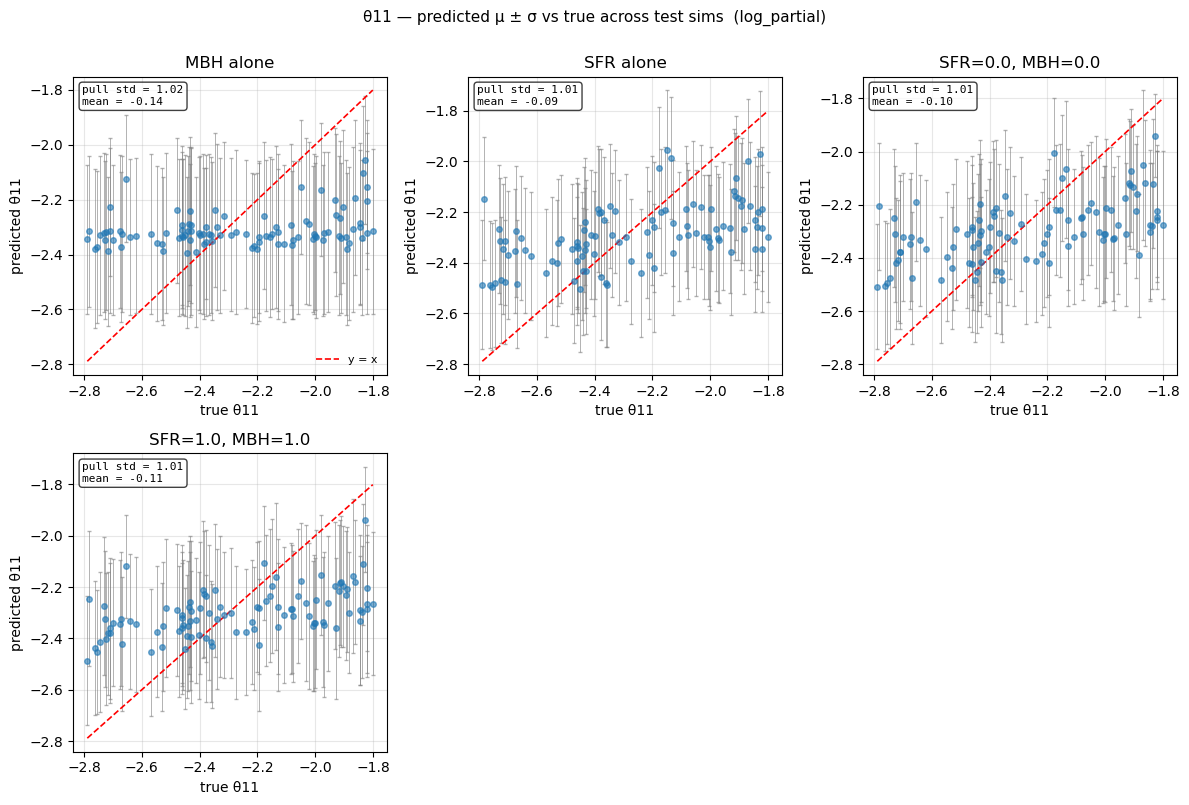

[warn] θ8: param 'θ8' not in any case's moment_focus_params.


In [32]:
if has_moment:
    for p in FOCUS_PARAMS:
        try:
            ctx.plots.plot_predictions_with_errorbars(p, cases=ctx.cases, space="log_partial")
            relabel_figure(ctx)
            plt.show()
        except Exception as e:
            print(f"[warn] {p}: {e}")

### 5b. Population σ per case per param — bar chart
Median predicted σ across all test sims, one bar group per case per param.

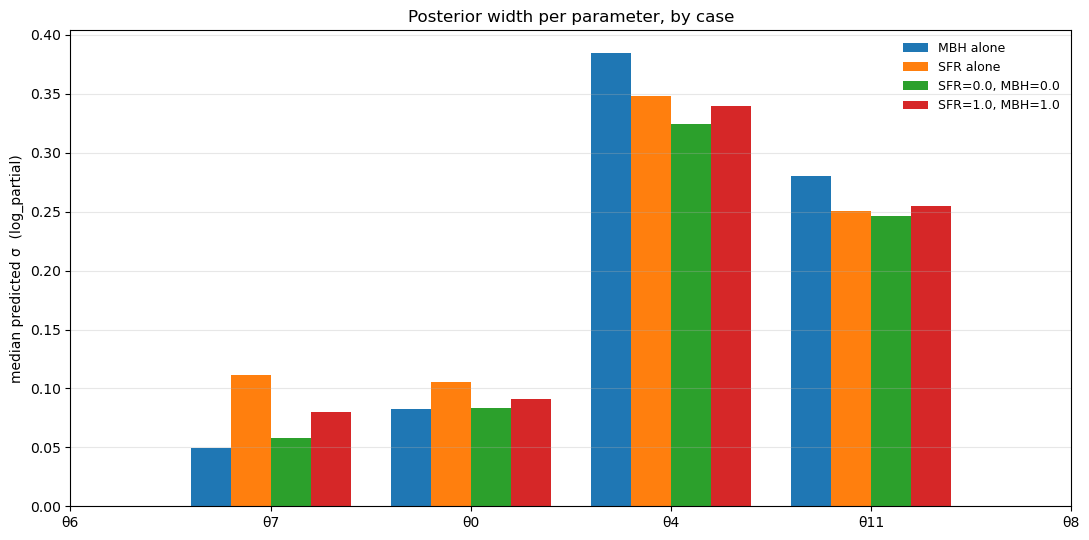

In [18]:
if has_moment:
    ctx.plots.plot_sigma_by_case_bars(FOCUS_PARAMS, ctx.cases,
                                       space="log_partial", reducer="median")
    relabel_figure(ctx)
    plt.show()

### 5c. Calibration — pull distribution per case
Well-calibrated → matches N(0, 1). std >> 1 ⇒ σ under-predicted (over-confident).
std < 1 ⇒ σ over-predicted (conservative). Mean shift ⇒ bias.

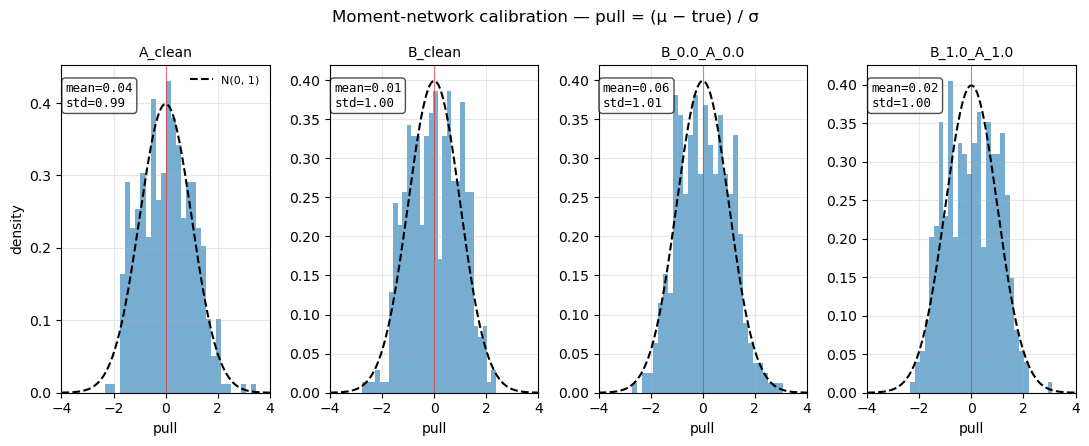

In [19]:
if has_moment:
    ctx.plots.plot_pull_distribution(ctx.cases, space="normalized", params=FOCUS_PARAMS)
    plt.show()

### 5d. Median correlation matrix per case
Off-diagonal darkness ⇒ param i and j are anti-correlated (opposite direction of error);
brightness ⇒ correlated. How correlation structure changes between cases reveals
which observable subsets break parameter degeneracies.

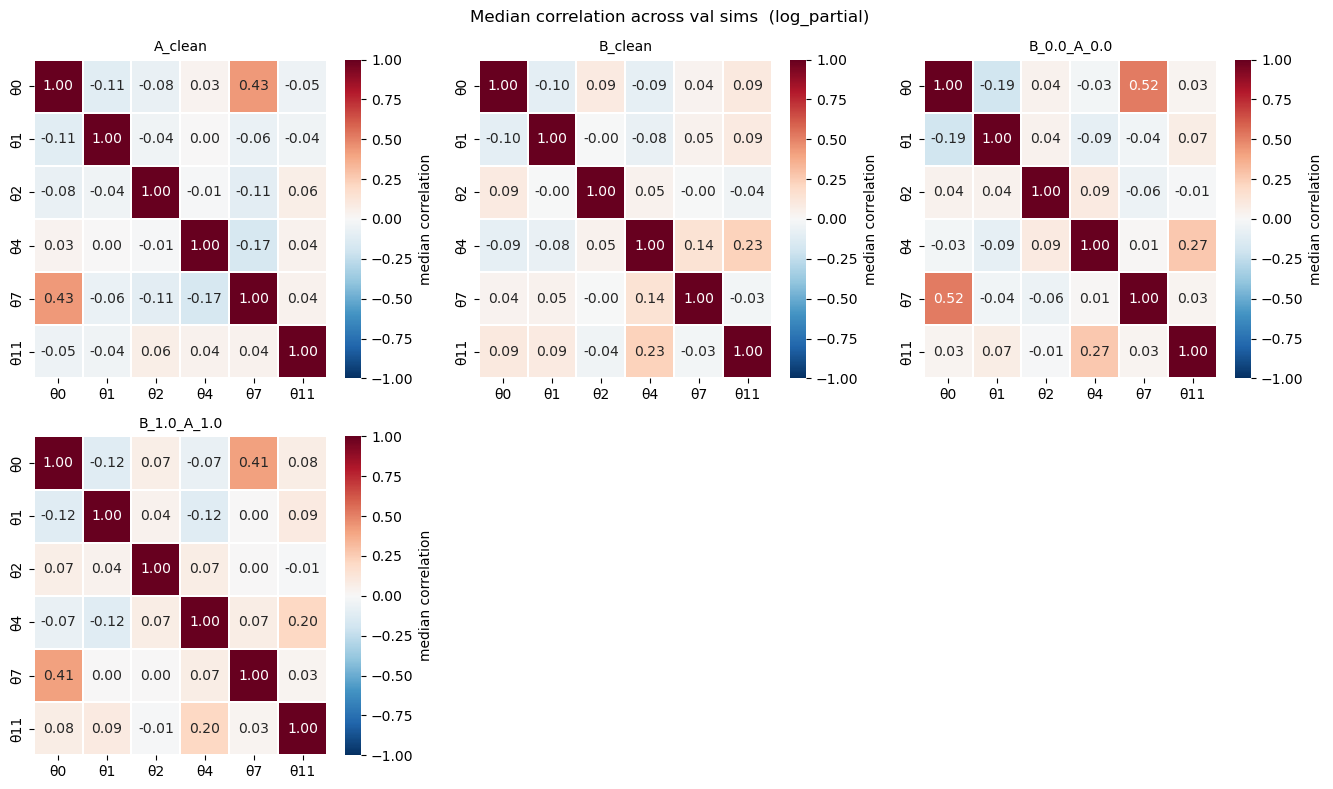

In [20]:
if has_moment:
    ctx.plots.plot_median_correlation_grid(ctx.cases, space="log_partial")
    plt.show()

### 5e. Corner plot — all cases overlaid, one representative sim
Full k×k joint posterior structure. Diagonal panels: 1D Gaussian marginals.
Off-diagonal panels: 2D uncertainty ellipses (1σ, 2σ). Truth marked in red.
Change `CORNER_SIM_IDX` to switch to a different validation sim.

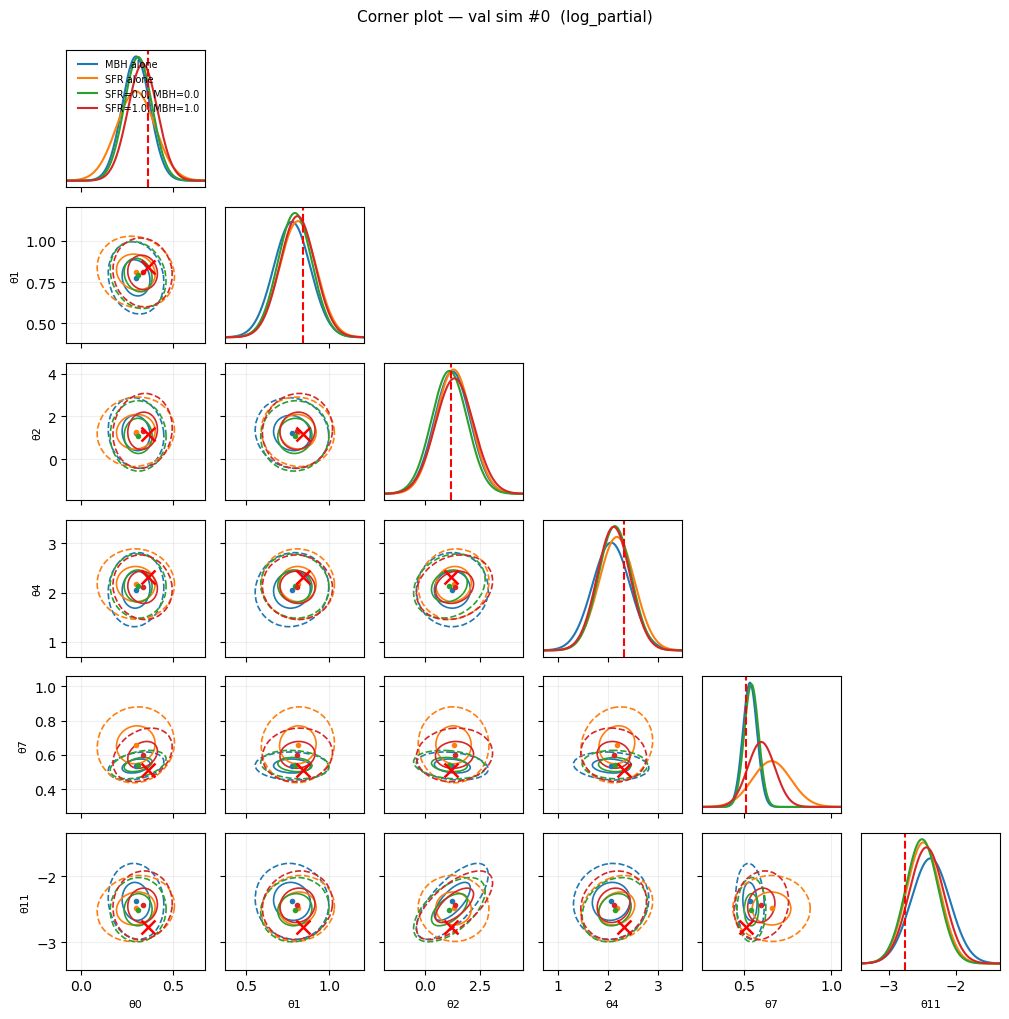

In [21]:
if has_moment:
    CORNER_SIM_IDX = 0
    ctx.plots.plot_corner(sim_idx=CORNER_SIM_IDX, cases=ctx.cases, space="log_partial")
    relabel_figure(ctx)
    plt.show()

### 5f. Prediction scatter corner — one per case
Aggregate view: scatter matrix of predicted μ across ALL test sims for one case.
Diagonal: histograms of predicted μ (blue) vs truth (grey).
Off-diagonal: scatter of (μ_j, μ_i) colored by residual magnitude, with the
median predicted 1σ ellipse overlaid.

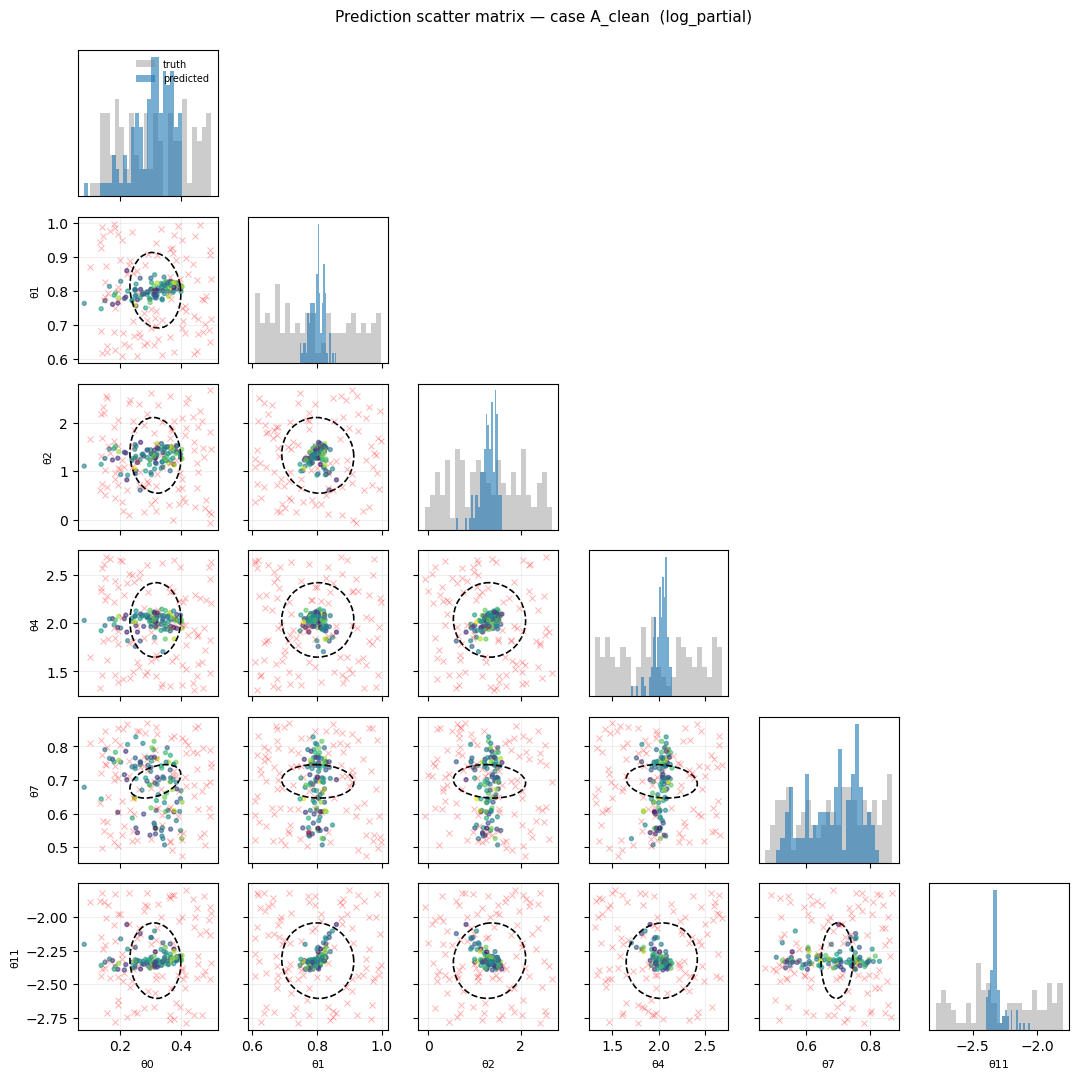

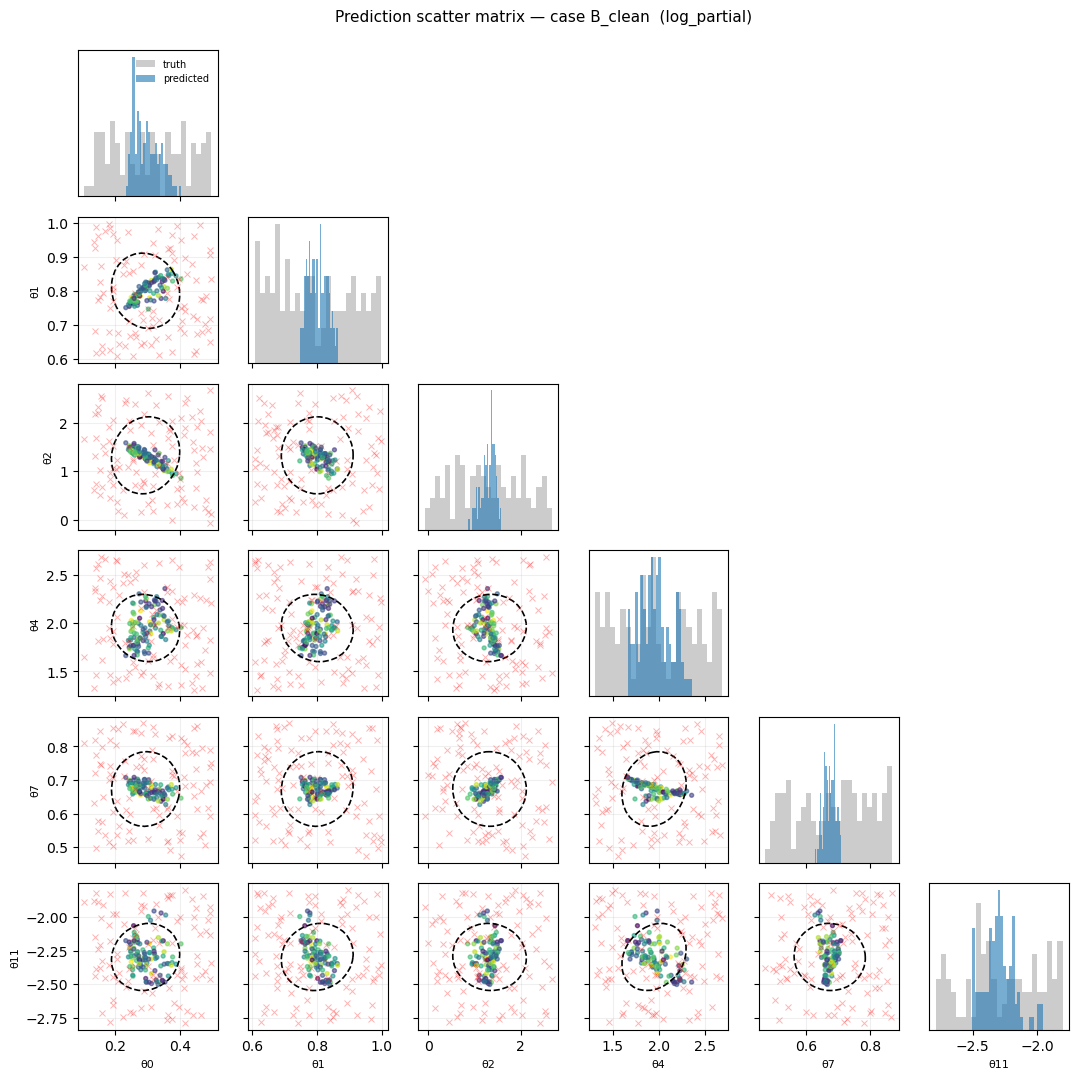

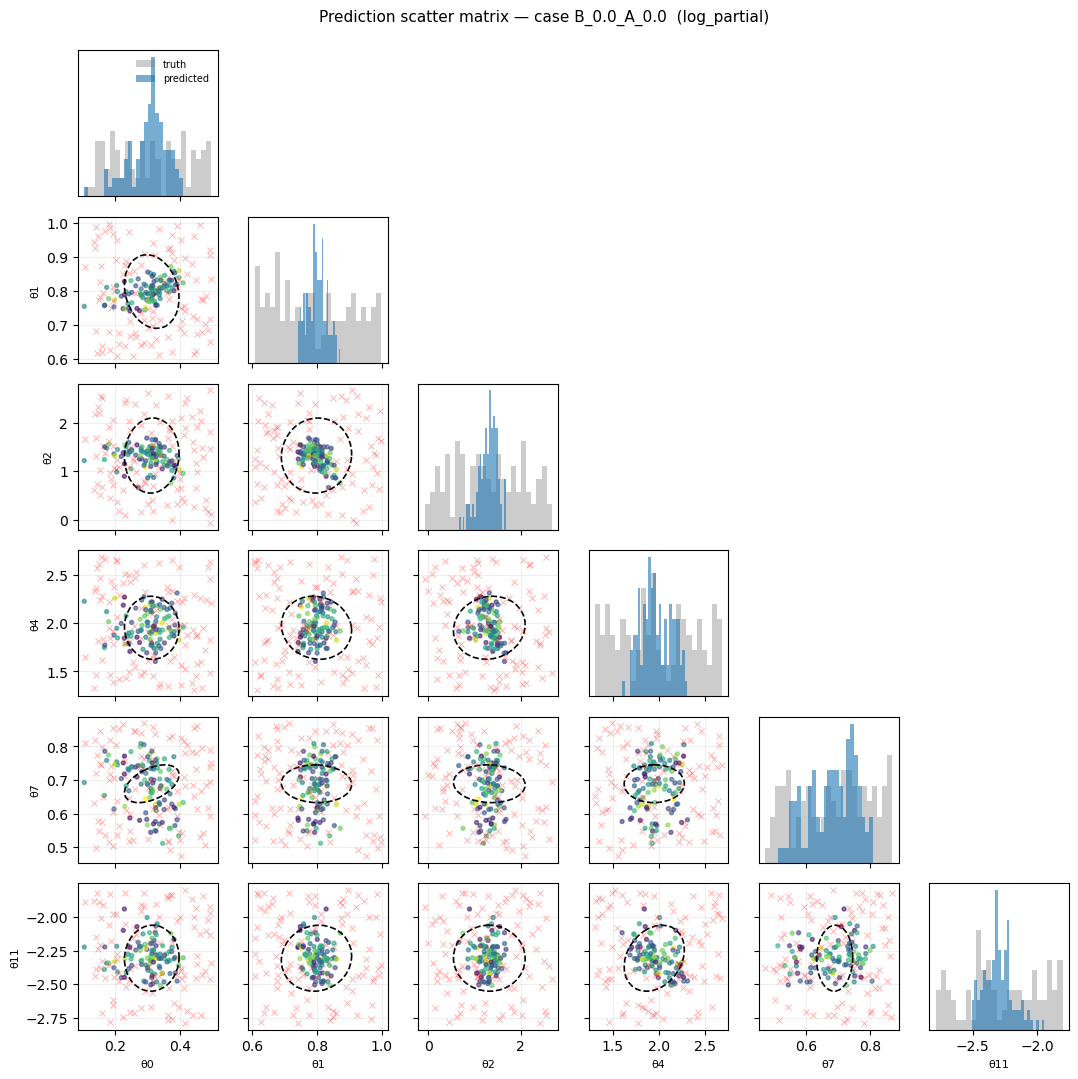

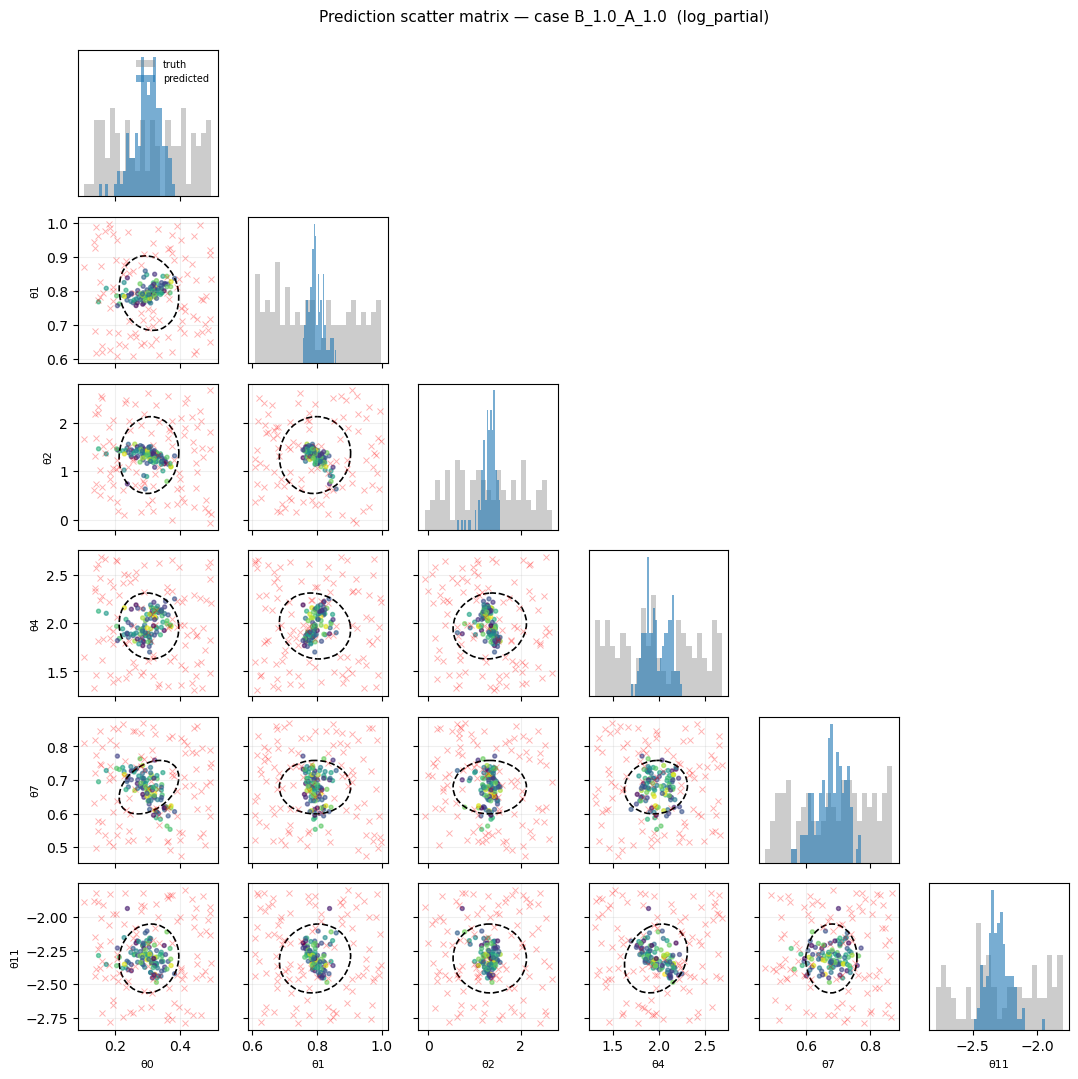

In [22]:
if has_moment:
    for c in ctx.cases:
        try:
            ctx.plots.plot_prediction_scatter_corner(c, space="log_partial")
            plt.show()
        except Exception as e:
            print(f"[warn] scatter_corner({c}): {e}")

## 6. Cross-pair comparison
Load every sweep pair (and optionally moment_example) and compare one param
across pairs for a chosen case.

In [23]:
all_ctxs = load_all_pairs(include_moment=True)
for c in all_ctxs:
    print(f"  {c.pair_dir.split('/')[-2]:50s}  obs1={c.obs1}  obs2={c.obs2}")

  pair_01_MBH_Mh_s61__SFR_Ms_s90                      obs1=MBH_Mh_s61  obs2=SFR_Ms_s90
  moment_example                                      obs1=MBH_Mh_s61  obs2=SFR_Ms_s90


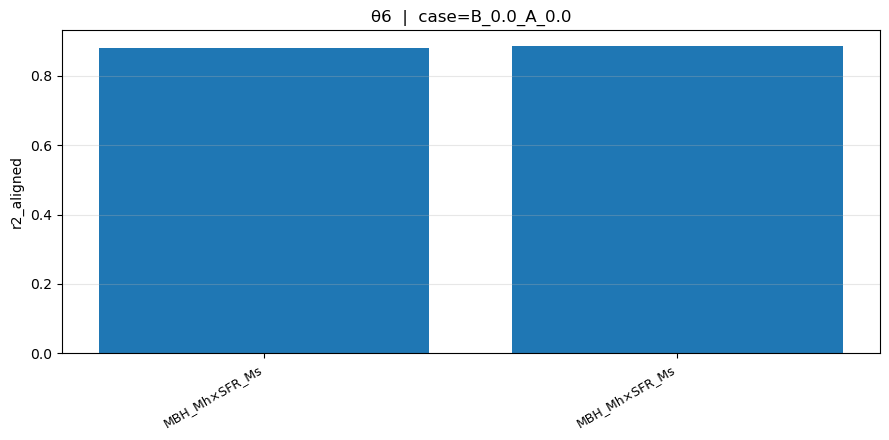

In [24]:
COMPARE_PARAM = FOCUS_PARAMS[0] if FOCUS_PARAMS else "θ4"
COMPARE_CASE = "B_0.0_A_0.0"       # both-clean; also try "B_1.0_A_1.0", "A_clean", "B_clean"

fig = compare_across_pairs(all_ctxs, COMPARE_PARAM, case_pattern=COMPARE_CASE,
                            metric="r2_aligned")
plt.show()

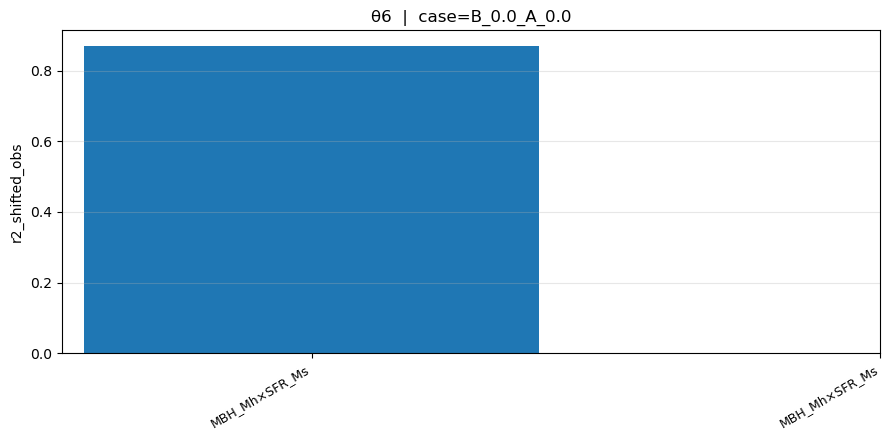

In [25]:
# Same param, but comparing the ΔR² (information lost when obs2 is shuffled)
try:
    fig = compare_across_pairs(all_ctxs, COMPARE_PARAM, case_pattern=COMPARE_CASE,
                                metric="r2_shifted_obs")
    plt.show()
except Exception as e:
    print(f"[warn] {e}")

[warn] no variance for /Users/nicolasgarcia/Downloads/GAL_SBI/camelsPE/jupyter_notebook_n/sweep/pair_01_MBH_Mh_s61__SFR_Ms_s90/results


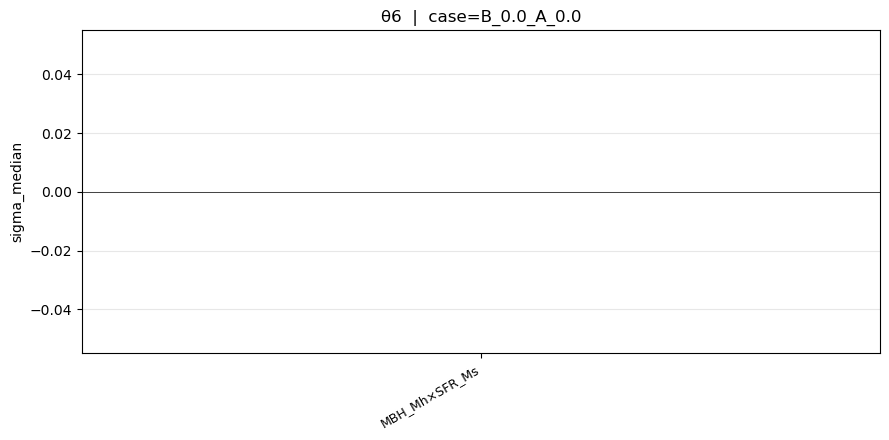

In [26]:
# If any of the loaded pairs has variance, compare median σ for this param
if any(c.has_variance for c in all_ctxs):
    fig = compare_across_pairs(all_ctxs, COMPARE_PARAM, case_pattern=COMPARE_CASE,
                                metric="sigma_median")
    plt.show()

## 7. Save the last figure
Explicit path so you can drop plots into your notes.

In [27]:
SAVE_DIR = os.path.join(ctx.results_dir, "plots", "notebook")
os.makedirs(SAVE_DIR, exist_ok=True)
# save the current figure (the last one shown) — call right after any plot cell
save_name = "custom_plot.png"
plt.gcf().savefig(os.path.join(SAVE_DIR, save_name), dpi=150, bbox_inches="tight")
print(f"saved {os.path.join(SAVE_DIR, save_name)}")

saved moment_example/results/plots/notebook/custom_plot.png


<Figure size 640x480 with 0 Axes>

## 8. Scratch — anything else you want to try
Every plot function from src/plots.py is available as `ctx.plots.<name>`.
Every pipeline helper as `ctx.pipeline.<name>`. Tab-complete in Jupyter.

In [28]:
# example: predict μ and σ (moment example only), print a table for one sim
if ctx.has_variance:
    SIM = 0
    print(f"Sim #{SIM}  — μ ± σ  (log_partial space)")
    for cidx, r in enumerate(ctx.all_results):
        mu, sigma, truth = ctx.pipeline.predict_with_uncertainty(r, space="log_partial")
        print(f"\n  case = {ctx.display_names[r['case_name']]}")
        for p in FOCUS_PARAMS:
            pidx = ctx.param_names.index(p)
            print(f"    {p:5s}  μ={mu[SIM,pidx]:+.3f}  σ={sigma[SIM,pidx]:.3f}  true={truth[SIM,pidx]:+.3f}"
                  f"   pull={(mu[SIM,pidx]-truth[SIM,pidx])/sigma[SIM,pidx]:+.2f}")

Sim #0  — μ ± σ  (log_partial space)

  case = MBH alone
    θ6     μ=+0.060  σ=nan  true=+0.064   pull=+nan
    θ7     μ=+0.535  σ=0.041  true=+0.514   pull=+0.52
    θ0     μ=+0.298  σ=0.076  true=+0.362   pull=-0.84
    θ4     μ=+2.060  σ=0.376  true=+2.323   pull=-0.70
    θ11    μ=-2.378  σ=0.288  true=-2.764   pull=+1.34
    θ8     μ=+0.925  σ=nan  true=+0.819   pull=+nan

  case = SFR alone
    θ6     μ=+0.050  σ=nan  true=+0.064   pull=+nan
    θ7     μ=+0.659  σ=0.111  true=+0.514   pull=+1.31
    θ0     μ=+0.297  σ=0.105  true=+0.362   pull=-0.62
    θ4     μ=+2.173  σ=0.357  true=+2.323   pull=-0.42
    θ11    μ=-2.486  σ=0.251  true=-2.764   pull=+1.11
    θ8     μ=+0.978  σ=nan  true=+0.819   pull=+nan

  case = SFR=0.0, MBH=0.0
    θ6     μ=+0.059  σ=nan  true=+0.064   pull=+nan
    θ7     μ=+0.544  σ=0.041  true=+0.514   pull=+0.72
    θ0     μ=+0.310  σ=0.076  true=+0.362   pull=-0.69
    θ4     μ=+2.133  σ=0.326  true=+2.323   pull=-0.58
    θ11    μ=-2.505  σ=0.244  t